
# `Материалы кафедры ММП факультета ВМК МГУ. Математические Методы Распознавания Образов.`

# `Семинар 05 (часть 2): Применение EM алгоритма для повышения качества изображений`

### `Материалы составил Оганов Александр (@welmud)`


#### `Москва, Весенний семестр 2025`

`Материалы`

- Основная статья "Bayesian Image Super-Resolution" [Tipping and Bishop, 2002](https://proceedings.neurips.cc/paper_files/paper/2002/file/88bfcf02e7f554f9e9ea350b699bc6a7-Paper.pdf)

- Реализация с некоторыми переработками взята из [не официального репазитория на GitHub](https://github.com/hrshtv/Bayesian-Image-Super-Resolution)

## `Постановка задачи`

Есть изображение $x$ в высоком разрешении, изображение содержит $N$ пикселей.

Мы наблюдаем (снимаем) $K$ изображений $\{ y^{(k)}\}_{k=1}^K$ в низком разрешении, которые чуть сдвинуты относительно друг друга и каждое по-своему размыто. Для определенности будем считать, что все $y^(K)$ сдвинуты относительно $y^{(1)}$. Каждое изображение в низком разрешении содержит $M$ пикселей.

**Цель:**

Найти изображение $x$ по наблюдаемым $\{ y^{(k)}\}_{k=1}^K$.

## `Практика`

**Пример 1**

Представим, что у нас есть статичная сцена, и мы фотографируем на телефон с не очень хорошей камерой. Мы получим следующие искажения:



- Некоторые пиксели немного изменятся;
- Некоторые пиксели сдвинутся друг относительно друга;
- На изображениях будут слегка разные физически обусловленные шумы.

**Пример 2**

Допустим, мы снимаем видео, и каждый отдельный кадр видео размытый. Однако при достаточной частоте кадров в секунду мы видим плавную и достаточно качественную картинку. Наша цель — из видео с большим числом кадров в секунду получить красивый кадр. Если мы выберем случайный кадр, то он будет размытым.

Сейчас все эти проблемы можно быстро решить с помощью нейронных сетей, однако такую задачу можно переформулировать вероятностно и обучиться на выборке при $K \leq 16$.

## `Вероятностная модель`

**Примечание 1:** Мы рассматриваем черно-белые изображения, каждый пиксель которых в диапазоне (-0.5, 0.5).

**Примечание 2:** Для краткости будем называть изображения в низком разрешении "плохими", а то, которое ищем в высоком "хорошим".

### `Априорное распределение`

Будем считать, что изображение в высоком разрешении это $x$, для которого задано априорное распределение:

\begin{align}
&p(x) = \mathcal{N}(x \mid 0, Z_x),\\
&Z_x = A \exp\{ - \frac{\|v_i - v_j\|^2}{r^2}\}.
\end{align}

Здесь $v_i$ обозначает координаты пикселя $i$ "хорошего" изображения в двумерном пространстве,
коэффициент $A \in \mathbf{R}$ измеряет "силу" априорного распределения, а $r$ - фактор, с которым мы учитываем влияние расстояния между пикселями $i$ и $j$ на их корреляцию.

Чем больше $r$, тем сильнее далекие пиксели скореллированы.

Чем больше $A$, тем больше дисперсия распределения. Дисперсия априорного влияет на разнообразие возможных изображений $x$.


Априорное распределение задает наше знание о мире. Мы предполагаем, что изображения в среднем около нуля и чем ближе пиксели, теперь сильнее они взаимодействуют.

### `Распределение "плохих" изображений`

Выше мы описали, что "плохие" изображения получились из "хорошего" через наложение шумов, сдвигов и других физических искажений. Попробуем придать этим искажениях математический формализм.

- Для эффекта шума можно добавить белый шум
- Для поворота умножить координаты пикселей на матрицу поворота
- Для размытия использовать фильтр размытия [(функция рассеяния точки/point spread function, PSF)](https://en.wikipedia.org/w/index.php?title=Point_spread_function&oldid=1257427643)

Тем самым мы получим следующую вероятностную модель.

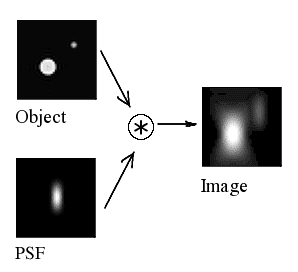

Изображение низкого разрешения получается в результате преобразования:

\begin{align}
y^{(k)} = W^{(k)} x + \varepsilon^{(k)}, \quad \varepsilon^{(k)} \sim \mathcal{N}(\varepsilon^{(k)} \mid 0, \beta^{-1} \mathbf{I}).
\end{align}

Параметр $\beta$ отвечает за дисперсию шума, который получается при съемке камерой. $W^{(k)} \in \mathbb{R}^{M \times N}$ задает размытие изображения и уменьшение разрешения изображения.

\begin{align}
&\hat{W}_{ij}^k = \exp \left(\frac{-\|v_i - u_j^{(k)} \|^2}{\gamma^2} \right), \\
&W_{ij}^k = \frac{\hat{W}_{ij}^k}{\sum_{i'}\hat{W}_{ij}^k},
\end{align}

где параметр $\gamma$ является неизвестным и отвечает за величину размытия, параметр $u_j^{(k)}$ задает центр размытия изображения, который зависит от сдвига и поворота "плохого" изображения.

Мы можем задать параметризацию, которая зависит только от центра изображения:

\begin{align}
u_j^{(k)} = R^{(k)}(v_j - \bar{v}) + \bar{v} + s_k,
\end{align}

где $R^{(k)}$ матрица поворота на угол $\theta_k$, а $\bar{v}$ задает центр изображения.

Так как $y^{(k)} = W^{(k)} x + \varepsilon^{(k)}$, мы получим вероятностную модель:
    
\begin{align}
&p(y^{(k)} \mid x, s_k, \theta_k, \gamma) = \mathcal{N}(y^{(k)} \mid W^{(k)} x, \beta^{-1} \mathbf{I})\\
&p(y^{(k)} \mid x, s_k, \theta_k, \gamma) = \biggl(\frac{\beta}{2\pi} \biggr)^{\frac{M}{2}}\exp\biggl( -\frac{\beta}{2}\| y^{(k)} - W^{(k)} x\|^2\biggr)
\end{align}

### `Рассуждения`

Мы ввели вероятностную модель, ввели априорное распределение на "хорошее" изображение. Прежде чем перейти к выписыванию EM алгоритма, надо ответить на следующие вопросы:

- Что является латентной переменной? Знание чего упростило бы задачу и позволяет выписать правдоподобие?

- Что мы хотим найти? Чем является $x$? На каком шаге мы найдем $x$: E или M?

- Какие параметры задают вероятностную модель? Что мы оптимизируем на M шаге?

### `Апостериорное распределение (E шаг)`

Мы знаем $p(x)$, знаем $p(y \mid x, \ldots)$. Значит можем найти апостериорное распределение $p(x \mid y, \ldots)$ по теореме Байеса. Кроме того известный факт, что если $p(x)$ и $p(y \mid x, \ldots)$ нормальные распределения, то апостериорное тоже будет нормальным.

Найдем апостериорное распределение.

\begin{align}
p(x \mid \{y^{(k)}, s_k, \theta_k \}, \gamma) = \frac{p(x) \prod_{k=1}^K p(y^{(k)} \mid x, s_k, \theta_k, \gamma)}{p(\{y^{(k)}\} \mid \{s_k, \theta_k \}, \gamma)} = \mathcal{N}(x \mid \mu, \Sigma)
\end{align}

Известны формулы:
\begin{align}
&\Sigma = [(Z^{-1}_x + \beta(\sum^K_{k=1} W^{{(k)}^T} W^{(k)})]^{-1},\\
&\mu = \beta \Sigma(\sum^K_{k=1} W^{{(k)}^T} y^{(k)}).
\end{align}

Мы не будем углубляться в вывод, подбронее об этом расскажут на курсе "Байесовские методы". Уточним лишь тот факт, что мы можем найти $\Sigma$, $\mu$ по функциональному виду $\mathcal{N}(x \mid \mu, \Sigma)$. В частности $\mu$ точка максимума правдоподобия (мода).

Тогда $E$ шаг означает:

\begin{align}
q(x) := p(x \mid \{y^{(k)}, s_k, \theta_k \}, \gamma)
\end{align}

## `Нахождение параметров (M шаг)`

Если бы мы знали параметры $\{s_k, \theta_k\}$ и параметр $\gamma$, то мы бы знали значения $W^{(k)}$ и легко бы решили задачу. К сожалению, эти параметры нам неизвестны, поэтому надо их найти.

Есть 2 способа:

- Записать M шаг и записать оптимизациионную задачу

- Воспользоваться принципом максимума обоснованности и оптимизировать обоснованность (узнаете на Байесовских методах)

#### `Максимум обоснованности`

В оригинальной статье пользуются именно вторым методом, так как он работает быстрее. Идейно наша цель максимизировать $p(y \mid \{s_k, \theta_k \}, \gamma) = \mathcal(y \mid, 0, Z_y)$, где $Z_y = \beta^{-1}\mathbf{I} + W Z_x W^T$.

Тогда задача формулируется как:

\begin{align}
&p(y \mid \{s_k, \theta_k \}, \gamma) \to \max_{\{s_k, \theta_k \}, \gamma}\\
&\log p(y \mid \{s_k, \theta_k \}, \gamma) \to \max_{\{s_k, \theta_k \}, \gamma}
\end{align}

### `Честный M шаг`

На M шаге мы масимизируем ELBO по парметрам, то есть решаем задачу:

\begin{align}
\int q(x) \log \frac{p(y, x \mid \{s_k, \theta_k \}, \gamma)}{q(x)} \mathrm{d}x \to \max_{\{s_k, \theta_k \}, \gamma}.
\end{align}

Начнем упрощать задачу, выбрасывая слагаемые, которые не влияют на решение оптимизации.

\begin{align}
&\int q(x) \log \frac{p(y, x \mid \{s_k, \theta_k \}, \gamma)}{q(x)} \mathrm{d}x \to \max_{\{s_k, \theta_k \}, \gamma},\\
&\int q(x) \log \frac{p(y \mid x, \{s_k, \theta_k \}, \gamma) p(x)}{q(x)} \mathrm{d}x \to \max_{\{s_k, \theta_k \}, \gamma},\\
&\int q(x) \log p(y \mid x, \{s_k, \theta_k \}, \gamma) \mathrm{d}x \to \max_{\{s_k, \theta_k \}, \gamma}.
\end{align}

Вспомним, что $p(y^{(k)} \mid x, s_k, \theta_k, \gamma) = \biggl(\frac{\beta}{2\pi} \biggr)^{\frac{M}{2}}\exp\biggl( -\frac{\beta}{2}\| y^{(k)} - W^{(k)} x\|^2\biggr)$

Заметим, что параметры по которым ведется оптимизация влияют только на $W^{(k)}$, поэтому задача выше эвививалетна оптимизации



\begin{align}
&\sum_{k=1}^K \mathbb{E}_{x \sim q(x)} \biggl[ -\frac{\beta}{2}\| y^{(k)} - W^{(k)} x\|^2\biggr] \to \max_{\{s_k, \theta_k \}, \gamma},\\
&\sum_{k=1}^K \mathbb{E}_{x \sim q(x)} \biggl[\| y^{(k)} - W^{(k)} x\|^2\biggr] \to \min_{\{s_k, \theta_k \}, \gamma}
\end{align}

## `Практические особенности`

Заметим, чтобы сделать честный E шаг по всему изображению надо обратить матрицу $Z_x$, так как $\Sigma = [(Z^{-1}_x + \beta(\sum^K_{k=1} W^{{(k)}^T} W^{(k)})]^{-1}$. Обратить матрицу порядка $N$ ($N$ - число пикселей), может быть вычислительно трудно, поэтому мы будем оценивать параметры модели и апостериорное распределение на патче изображении.

Под патчем мы понимаем маленькую часть исходного изображения, которая содержит в себе достаточно информации о преобразованиях, например, центральный кроп размером в 2 раза меньше исходного изображения.

## `Реализация`

In [1]:
# General
import os
import time
import random
from tqdm.notebook import tqdm

# Image Processing
import cv2
from PIL import Image
from matplotlib import image

# Tensor Processing
import torch
import numpy as np

# Plotting
from matplotlib import pyplot as plt

#### `Функции для работы с изображением`

In [2]:
def scale(img):
    """ Scales the img to [-0.5, 0.5] """
    img_s = (img - img.min()) / (img.max() - img.min()) # scale to [0, 1]
    img_s = img_s - 0.5 # scale to [-0.5, 0.5]
    img_s = img_s.float()
    return img_s

In [3]:
def disp(img, out_path = None, show=True):
    """ Displays an image, and saves it to out_path if specified """

    # Convert to NumPy array
    if type(img) == torch.Tensor:
        if img.is_cuda:
            # Shift to CPU from GPU
            img = img.data.cpu().numpy()
        else:
            img = img.numpy()
    
    plt.imshow(img, cmap = "gray")
    plt.axis("off")
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi = 100, bbox_inches = "tight", format = "jpg", pad_inches = 0)
    
    if show:
        plt.show()
    else:
        plt.close()

In [4]:
def load(path):
    """ Reads an image and performs pre-processing """
    img = cv2.imread(path, 0) # Read in grayscale
    img = Image.fromarray(img) # Convert to PIL Image for downsizing
    img = img.resize((SHAPE_HR[1], SHAPE_HR[0]), Image.Resampling.LANCZOS) # OpenCV doesn't have an ANTIALIAS option
    img = np.array(img) # Back to NumPy
    img = img.reshape(N, 1) # Unroll
    img = torch.from_numpy(img.copy()).to(DEVICE) # Convert to torch tensor
    img = img.float() # To FloatTensor
    img = scale(img) # Scale values in [-1/2, 1/2] as specified in the paper
    return img

In [5]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_global_seed(42)

In [6]:
# Connect to a GPU
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
    
DEVICE

'cuda'

### `Параметры изображения`

In [7]:
PATH_IMG = "butterfly.png" # Change this accordingly

# Row x Column format is used everywhere

SHAPE_ORIG_HR  = [120, 120] # original HR shape
SHAPE_PATCH_HR = [60, 60]   # shape of the HR patch

UPSCALE_FACTOR = 4

SHAPE_ORIG_LR  = [dim//UPSCALE_FACTOR for dim in SHAPE_ORIG_HR]
SHAPE_PATCH_LR = [dim//UPSCALE_FACTOR for dim in SHAPE_PATCH_HR]

K = 16                       # Num of LR images
SIGMA_AGN = 0.01

In [8]:
SHAPE_HR = SHAPE_ORIG_HR
SHAPE_LR = SHAPE_ORIG_LR

N = SHAPE_HR[0] * SHAPE_HR[1]
M = SHAPE_LR[0] * SHAPE_LR[1]

CENTER_HR = [dim//2 for dim in SHAPE_HR]
CENTER_HR = torch.tensor(CENTER_HR, dtype = torch.float).reshape(2, 1).to(DEVICE)

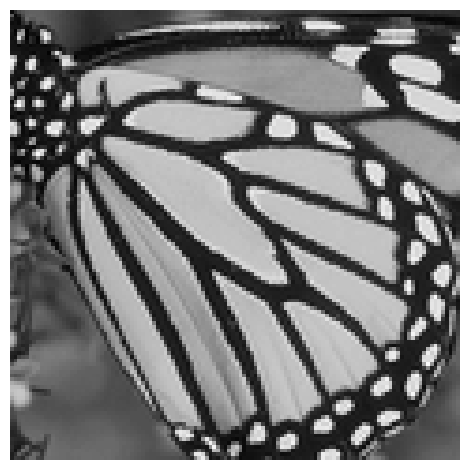

In [9]:
img = load(PATH_IMG)
disp(img.reshape(SHAPE_HR), "hr.jpg")

### `Априорное распределение`

\begin{align}
&p(x) = \mathcal{N}(x \mid 0, Z_x),\\
&Z_x = A \exp\{ - \frac{\|v_i - v_j\|^2}{r^2}\}.
\end{align}

In [10]:
from torch.distributions import MultivariateNormal

In [11]:
# Prior Parameters
PRIOR_STRENGTH       = 0.04
PRIOR_CORR_LEN_SCALE = 1

In [12]:
def priorCovariance(A, r, vi):
    """ Returns the NxN prior covariance matrix Z_x as specified in the paper """

    dist_sq = -(torch.cdist(vi.T, vi.T) ** 2)
    Zx = A * torch.exp((1 / r ** 2) * dist_sq)
    
    return Zx

Для подсчета правдоподобия будем использовать `torch.distributions.MultivariateNormal`, однако при вызове класса строится разложение Холецкого. Мы будем это учитывать, чтобы не создать накладных расходов.

Функция реализована в коде с [GitHub](https://github.com/hrshtv/Bayesian-Image-Super-Resolution) содержит ошибку

In [13]:
# def logPriorGaussian(prior_dist, x):
#     """ Returns the log prior """
    
# #     PRIOR_DIST = MultivariateNormal(
# #         torch.zeros(Zx.shape[0]).to(DEVICE),
# #         covariance_matrix=Zx
# #     )
    
#     return prior_dist.log_prob(x.flatten())

# Версия с GitHub, какую ошибку вы видите?
def logPriorGaussian(prior_dist, x):
    """ Returns the log prior """
    term1 = N * logdet_Zx
    term2 = torch.mm(x.T, Zx_inv)
    term2 = torch.mm(term2, x) # x^T Z_x^{-1} x
    log_prior = -0.5 * (term1 + term2) 
    
    return log_prior

### `Как портить изображения`

Нам часто надо будет работать с $v_i$, поэтому зададим функцию получения кординат пикселей.

In [14]:
def positions(shape):
    """ Returns the 2 x N coordinate tensor """
    v = np.indices(shape)
    v = v.reshape(2, -1)
    v = torch.from_numpy(v)
    v = v.float().to(DEVICE)
    return v

Для сдвига и поворота воспользуемся функциями ниже.

In [15]:
def getRotationMatrix(theta): # involves theta
    """ Returns the 2x2 rotation matrix, theta assumed to be in degrees """
    theta_rad = (np.pi / 180) * theta # To radians
    R = torch.empty(2, 2, dtype = torch.float).to(DEVICE)
    R[0, 0] = torch.cos(theta_rad)
    R[0, 1] = torch.sin(theta_rad)
    R[1, 0] = -torch.sin(theta_rad)
    R[1, 1] = torch.cos(theta_rad)
    
    return R

def shiftAndRotate(R, s): # involves theta
    """ Returns the u_j^(k)s as defined in the paper """
    u = R @ (V_LR - CENTER_HR) + CENTER_HR + s
    return u

Функцию PSF возьмем из статьи.

In [16]:
def transform(s, theta, gamma):
    """ Returns W as defined in the paper by Tipping et al. """

    R = getRotationMatrix(theta)

    # The PSF arra
    u = shiftAndRotate(R, s) # [2, M]

    dist_sq = - torch.cdist(u.T, V_HR.T)**2

    # W[i, j] = exp(-(|| u[i] - v[j] ||^2 / gamma^2)), this takes the most time
    W = torch.exp((1 / (gamma ** 2)) * dist_sq)

    # The normalizing factor (like softmax)
    scale = torch.sum(W, dim = 1).reshape(-1, 1) # [M, 1]

    # W[i, j] = exp(-(|| u[i] - v[j] ||^2 / gamma^2)) / sum_j (exp(-(|| u[i] - v[j] ||^2 / gamma^2)))
    W = W / scale

    return W

In [17]:
def synthLRSingle(img, sigma, s = None, theta = None, gamma = None):
    """ Returns the LR image as a numpy array"""

    # Shift + Rotate + PSF
    if s == None and theta == None and gamma == None:
        sx = random.uniform(-2, 2) / 3 # Since we are using 1/3 image dims compared to the paper
        sy = random.uniform(-2, 2) / 3
        s  = torch.tensor([sx, sy], dtype = torch.float).reshape(2, 1).to(DEVICE)
        theta = torch.tensor(random.uniform(-4, 4)).to(DEVICE) / 3 # Rotation value in degrees
        gamma = 2

    W_k = transform(s, theta, gamma)

    # Additive Gaussian Noise
    eps = sigma * torch.randn(M, 1).to(DEVICE) # ~ N(0, sigma^2), sigma^2 = 1/beta in the paper

    img_lr = torch.mm(W_k, img) + eps

    img_lr = scale(img_lr)

    return img_lr

Реализуем случайные преобразования.

In [18]:
def getRandomShifts(a, b):
    """ Returns a Kx2x1 tensor randomly initialized using values between a and b """
    s = (b - a) * np.random.rand(K, 2, 1) + a
    s = s.tolist()
    s = [torch.tensor(s_i, dtype = torch.float).to(DEVICE) for s_i in s]
    return s

def getRandomAngles(a, b):
    """ Returns a Kx1 tensor randomly initialized using values between a and b """
    theta = (b - a) * np.random.rand(K, 1) + a
    theta = theta.tolist()
    theta = [torch.tensor(theta_i, dtype = torch.float).to(DEVICE) for theta_i in theta]
    return theta

def synthLRMultiple(img, sigma, s_list = None, theta_list = None, gamma = None):
    """ Returns a list of K LR images and the list of shifts, angles used for creating them """

    if s_list == None and theta_list == None and gamma == None:
        s_list     = getRandomShifts(-0.65, 0.65) # ~2/3
        theta_list = getRandomAngles(-1.35, 1.35) # ~4/3
        gamma = 2

    y = [synthLRSingle(img, sigma, s_list[k], theta_list[k], gamma) for k in range(K)]

    return y, s_list, theta_list

### `Условное распределение`

In [19]:
from torch.distributions import Normal

При нахождении апостериорного распределения, нам потребуется посчитать $p({y} \mid x) = \prod_{k=1}^K p(y^{(k)} \mid x)$

\begin{align}
&p(y^{(k)} \mid x, s_k, \theta_k, \gamma) = \mathcal{N}(y^{(k)} \mid W^{(k)} x, \beta^{-1} \mathbf{I})\\
&p(y^{(k)} \mid x, s_k, \theta_k, \gamma) = \biggl(\frac{\beta}{2\pi} \biggr)^{\frac{M}{2}}\exp\biggl( -\frac{\beta}{2}\| y^{(k)} - W^{(k)} x\|^2\biggr)
\end{align}

In [20]:
def logLikelihood(x, y, W, sigma):
    """ Returns the log likelihood """
    
    log_likelihood = 0
    for k in range(len(W)):
        dist = Normal((W[k] @ x)[:, 0], sigma)
        term = dist.log_prob(y[k][:, 0]).sum()
        log_likelihood += term
    
    
    return log_likelihood

### `Апостериорное распределение`

\begin{align}
p(x \mid \{y^{(k)}, s_k, \theta_k \}, \gamma) = \frac{p(x) \prod_{k=1}^K p(y^{(k)} \mid x, s_k, \theta_k, \gamma)}{p(\{y^{(k)}\} \mid \{s_k, \theta_k \}, \gamma)} = \mathcal{N}(x \mid \mu, \Sigma)
\end{align}

\begin{align}
&\Sigma = [(Z^{-1}_x + \beta(\sum^K_{k=1} W^{{(k)}^T} W^{(k)})]^{-1},\\
&\mu = \beta \Sigma(\sum^K_{k=1} W^{{(k)}^T} y^{(k)}).
\end{align}


In [21]:
def posteriorCovariance(W, sigma, Zx_inv):
    """ Returns the covariance of the Gaussian formed by the posterior """
    
    temp = 0.
    for k in range(len(W)):
        temp += torch.mm(W[k].T, W[k])
    
    C = torch.inverse(Zx_inv + ((1 / sigma**2) * temp)).float()
    
    return C

In [22]:
def posteriorMean(y, C, W, sigma):
    """ Returns the mean of the Gaussian formed by the posterior """

    temp = 0.
    for k in range(len(W)):
        temp += torch.mm(W[k].T, y[k])

    mu = (1/sigma**2) * torch.mm(C, temp)

    return mu

### `Оптимизация`

Мы будем использовать принцип максимума обоснованности, так как он сходится быстрее (по экспериментальным результатам)

\begin{align}
\log p(y \mid \{s_k, \theta_k \}, \gamma) \to \max_{ \{s_k, \theta_k\}, \gamma}
\end{align}


In [23]:
def marginalLogLikelihood(y, W, C, mu, sigma, Zx_inv, logdet_Zx):
    """ Returns the marginal likelihood, using the Gaussian prior """

    term1 = 0.
    for k in range(K):
        Wmu = torch.mm(W[k], mu)
        term1 += torch.sum((y[k] - Wmu)**2)
    term1 = (1 / (sigma**2)) * term1

    term2 = torch.mm(Zx_inv, mu)
    term2 = torch.mm(mu.T, term2)

    mll = -0.5 * (term1 + term2 - logdetSPD(C) + logdet_Zx + 2*K*M*np.log(sigma)) # logdet takes the most time

    return mll

### `Создание выборки`

In [24]:
set_global_seed(42)

In [25]:
# Pre-compute v_hr for reuse
V_HR  = positions(SHAPE_HR)
V_LR  = UPSCALE_FACTOR * positions(SHAPE_LR)

In [26]:
# Get the list of LR images
y, shifts_true, angles_true = synthLRMultiple(img, SIGMA_AGN)
gamma_true = 2

In [27]:
shifts_true[0], shifts_true[-1]

(tensor([[-0.1631],
         [ 0.5859]], device='cuda:0'),
 tensor([[ 0.1398],
         [-0.4283]], device='cuda:0'))

In [28]:
angles_true[0], angles_true[-1]

(tensor([-1.1744], device='cuda:0'), tensor([0.0542], device='cuda:0'))

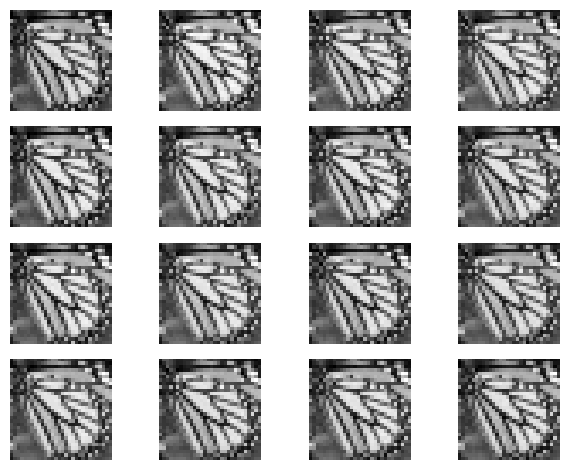

In [29]:
nrow = int(np.sqrt(K))

fig, ax = plt.subplots(nrow, nrow)
for k in range(K):
    img_p = y[k].reshape(SHAPE_LR)
    img_p = img_p.detach().cpu().numpy()
    ax.ravel()[k].imshow(img_p, cmap='gray')
    ax.ravel()[k].axis('off')
    
plt.tight_layout()

### `Патч`

Оценим параметры модели, а именно сдвиги, повороты и $\gamma$ по патчу с целью повышения эффективности.

In [30]:
def getPatch(img, shape, shape_orig, cx, cy):
    """ Get's a shape x shape patch centered at (cx, cy) """
    x_start = cx - shape[0]//2
    x_end   = x_start + shape[0]
    y_start = cy - shape[1]//2
    y_end   = y_start + shape[1]
    patch = img.reshape(shape_orig)
    patch = patch[x_start:x_end, y_start:y_end]
    patch = patch.reshape(-1, 1)
    return patch

In [31]:
y_patches = [getPatch(y[k], SHAPE_PATCH_LR, SHAPE_ORIG_LR, SHAPE_ORIG_LR[0]//2, SHAPE_ORIG_LR[1]//2) for k in range(K)]

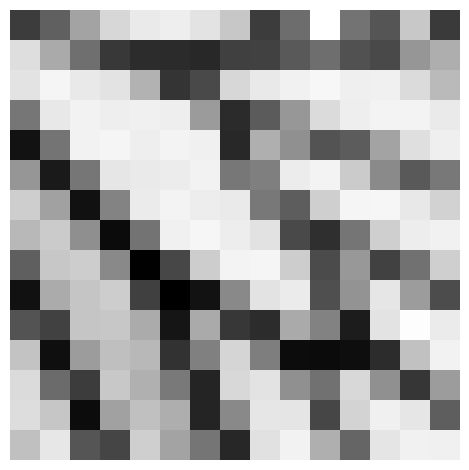

In [32]:
disp(y_patches[0].reshape(SHAPE_PATCH_LR), "patch.jpg")

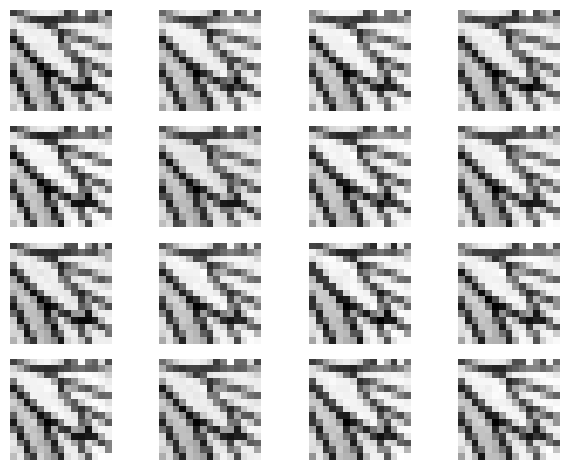

In [33]:
nrow = int(np.sqrt(K))

fig, ax = plt.subplots(nrow, nrow)
for k in range(K):
    img_p = y_patches[k].reshape(SHAPE_PATCH_LR)
    img_p = img_p.detach().cpu().numpy()
    ax.ravel()[k].imshow(img_p, cmap='gray')
    ax.ravel()[k].axis('off')
    
plt.tight_layout()

In [34]:
SHAPE_HR = SHAPE_PATCH_HR
SHAPE_LR = SHAPE_PATCH_LR

N = SHAPE_HR[0] * SHAPE_HR[1]
M = SHAPE_LR[0] * SHAPE_LR[1]

CENTER_HR = [dim//2 for dim in SHAPE_HR]
CENTER_HR = torch.tensor(CENTER_HR, dtype = torch.float).reshape(2, 1).to(DEVICE)

# Pre-compute v_hr for reuse
V_HR  = positions(SHAPE_HR)
V_LR  = UPSCALE_FACTOR * positions(SHAPE_LR)

In [35]:
logdetSPD = lambda X : 2*torch.linalg.cholesky(X, upper = False).diagonal(dim1 = -2, dim2 = -1).log().sum(-1)

In [36]:
# Zx is constant throughout and thus is made global, thus, precompute Z_x, Z_x^{-1} and log(|Z_x)
Zx = priorCovariance(A=PRIOR_STRENGTH, r=PRIOR_CORR_LEN_SCALE, vi=V_HR) 
Zx = Zx.to(DEVICE)
Zx_inv = torch.inverse(Zx)
logdet_Zx = logdetSPD(Zx)

# We don't need Zx anymore
del Zx
torch.cuda.empty_cache() # after this, a total of 2.03 GB is occupied

In [37]:
shifts = np.zeros((K, 2, 1)) # [K, 2, 1]
shifts = shifts.tolist()
shifts = [torch.tensor(s).float().to(DEVICE) for s in shifts]

In [38]:
angles = np.zeros((K, 1))
angles = angles.tolist()
angles = [torch.tensor(theta).float().to(DEVICE) for theta in angles]

In [39]:
gamma = torch.tensor(UPSCALE_FACTOR).float().to(DEVICE)
gamma.requires_grad  = True

In [40]:
params = [gamma]

for k in range(K):

    shifts[k].requires_grad = True
    params.append(shifts[k])

    angles[k].requires_grad = True
    params.append(angles[k])

Отметим, что мы не стремимся идеально решить задачу оптимизации, поскольку оцениваем параметры по патчу. Если мы получим идеальное решение, то, скорее всего, переобучимся, и у параметров будет плохая обобщаемость на всё изображение.

In [41]:
N_EPOCH_MAX = 100
LR = 0.05 # 0.005 -> slower convergence, 0.5 -> everything goes wrong

optimizer = torch.optim.AdamW(
    params,
    lr = LR
)

In [42]:
losses = []
pbar = tqdm(range(N_EPOCH_MAX))
for i in pbar:

    optimizer.zero_grad()
    
    W = [transform(shifts[k], angles[k], gamma) for k in range(K)]
    C  = posteriorCovariance(W, SIGMA_AGN, Zx_inv=Zx_inv)
    mu = posteriorMean(y_patches, C, W, SIGMA_AGN)

    torch.cuda.empty_cache()

    loss = -1*marginalLogLikelihood(y_patches, W, C, mu, SIGMA_AGN, Zx_inv=Zx_inv, logdet_Zx=logdet_Zx)
    loss.backward()

    torch.cuda.empty_cache()


    optimizer.step()

    loss_scalar = loss.item()
    losses.append(loss_scalar)
    
    pbar.set_description(f"Loss: {loss_scalar:.4f}")

    torch.cuda.empty_cache()

  0%|          | 0/100 [00:00<?, ?it/s]

In [43]:
# No need of these anymore

del Zx_inv
del logdet_Zx
torch.cuda.empty_cache()

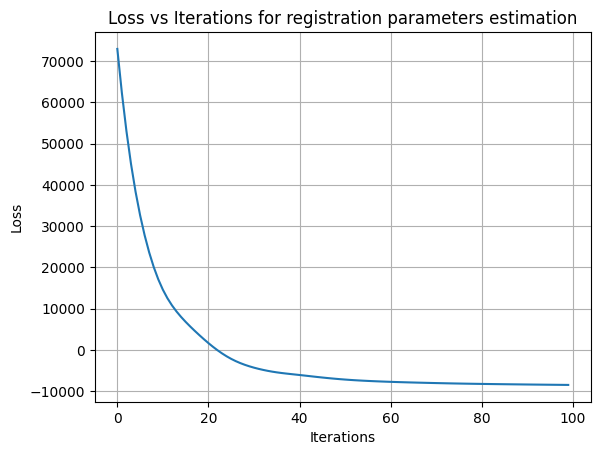

In [44]:
plt.plot(range(len(losses)), losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations for registration parameters estimation")
plt.grid()
plt.show()

In [45]:
for p in params:
    p.requires_grad = False

In [46]:
shifts_list_est_x = []
shifts_list_est_y = []
shifts_list_true_x = []
shifts_list_true_y = []

angles_list_est = []
angles_list_true = []

In [47]:
for k in range(K):

    s_est  = shifts[k].data.cpu().numpy()
    s_true = shifts_true[k].data.cpu().numpy()

    print(f"Shifts | True: {np.around(s_true, 3).ravel()} \t| Estimated: {np.around(s_est, 3).ravel()}")

    shifts_list_est_x.append(s_est[0])
    shifts_list_est_y.append(s_est[1])

    shifts_list_true_x.append(s_true[0])
    shifts_list_true_y.append(s_true[1])

    a_true = angles_true[k].item()
    a_est = angles[k].item()

    print(f"Angles | True: {a_true:.3f} \t\t| Estimated: {a_est:.3f}\n")

    angles_list_est.append(a_est)
    angles_list_true.append(a_true)

print(f"Gamma | True Gamma: {gamma_true} \t\t| Estimated: {gamma:.3f}")

Shifts | True: [-0.163  0.586] 	| Estimated: [0.004 0.67 ]
Angles | True: -1.174 		| Estimated: -1.318

Shifts | True: [0.302 0.128] 	| Estimated: [0.57  0.129]
Angles | True: 1.212 		| Estimated: 1.288

Shifts | True: [-0.447 -0.447] 	| Estimated: [-0.221 -0.463]
Angles | True: 1.257 		| Estimated: 1.231

Shifts | True: [-0.574  0.476] 	| Estimated: [-0.432  0.419]
Angles | True: 0.833 		| Estimated: 0.891

Shifts | True: [0.131 0.27 ] 	| Estimated: [0.271 0.273]
Angles | True: -0.528 		| Estimated: -0.597

Shifts | True: [-0.623  0.611] 	| Estimated: [-0.544  0.628]
Angles | True: -1.086 		| Estimated: -1.118

Shifts | True: [ 0.432 -0.374] 	| Estimated: [ 0.636 -0.432]
Angles | True: 0.497 		| Estimated: 0.506

Shifts | True: [-0.414 -0.412] 	| Estimated: [-0.295 -0.476]
Angles | True: -0.162 		| Estimated: -0.197

Shifts | True: [-0.254  0.032] 	| Estimated: [-0.146  0.038]
Angles | True: -1.020 		| Estimated: -1.107

Shifts | True: [-0.088 -0.271] 	| Estimated: [ 0.063 -0.278]
Ang

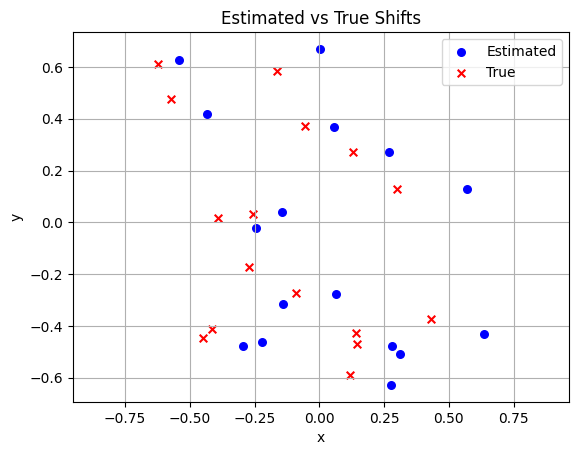

In [48]:
plt.scatter(shifts_list_est_x, shifts_list_est_y, s = 30, c = "b")
plt.scatter(shifts_list_true_x, shifts_list_true_y, s = 30, c = "r", marker = "x")
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Estimated vs True Shifts")
plt.legend(["Estimated", "True"])
plt.grid()
plt.show()

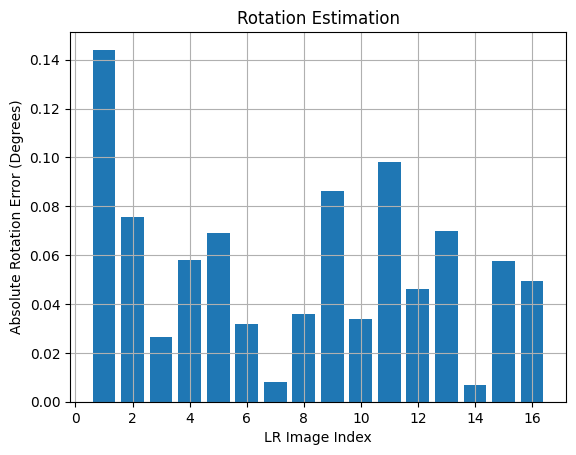

In [49]:
angles_diffs = []
for k in range(K):
    abs_diff = abs(angles_list_est[k] - angles_list_true[k])
    angles_diffs.append(abs_diff)

plt.bar(x = range(1, K+1), height = angles_diffs)
plt.xlabel("LR Image Index")
plt.ylabel("Absolute Rotation Error (Degrees)")
plt.title("Rotation Estimation")
plt.grid()
plt.show()

### `Как оценка качества`

In [50]:
def PSNR(x1, x2):
    """ Computes the PSNR between two images """
    x1 = scale(x1)
    x2 = scale(x2)
    mse = torch.mean((x1 - x2) ** 2)
    return 10 * torch.log10(1 / mse)

## `Высокое разрешение (MAP)`

Выше по патчу мы оценили параметры вероятностной модели. Теперь наша цель получить изображение в высоком разрешение, то есть найти апостериорное распределение на латентную переменную $x$.

На практике сделать $E$ шаг может быть дорого (надо обращать матрицу), поэтому мы будем искать точку максимума апостериорного распределение (Maximum a posteriori/MAP). Заметим, что в случае нормального распределения **MAP** совпадает с **математическим ожидаем**. Наша цель решить задачу:


\begin{align}
p(x \mid \{y^{(k)}, s_k, \theta_k \}, \gamma) = \frac{p(x) \prod_{k=1}^K p(y^{(k)} \mid x, s_k, \theta_k, \gamma)}{p(\{y^{(k)}\} \mid \{s_k, \theta_k \}, \gamma)} \to \max_{x}.
\end{align}

Заметим, что нормирочная константа не влияет на точку максимума (именно ее нам и трудно считать, так как надо знать матрицу $\Sigma$), то есть задача выше эквивалетна:

\begin{align}
&p(x) \prod_{k=1}^K p(y^{(k)} \mid x, s_k, \theta_k, \gamma) \to \max_{x}\\
&p(y^{(k)} \mid x, s_k, \theta_k, \gamma) = \mathcal{N}(y^{(k)} \mid W^{(k)} x, \beta^{-1} \mathbf{I})\\
&p(x) = \mathcal{N}(x \mid 0, Z_x)
\end{align}

In [51]:
def logPosteriorGaussian_UN(prior_dist, x, y, W, sigma):
    """ Returns the log posterior without normalizing constant"""
    log_posterior = logPriorGaussian(prior_dist, x) + logLikelihood(x, y, W, sigma)
    return log_posterior

In [52]:
SHAPE_HR = SHAPE_ORIG_HR
SHAPE_LR = SHAPE_ORIG_LR

N = SHAPE_HR[0] * SHAPE_HR[1]
M = SHAPE_LR[0] * SHAPE_LR[1]

CENTER_HR = [dim//2 for dim in SHAPE_HR]
CENTER_HR = torch.tensor(CENTER_HR, dtype = torch.float).reshape(2, 1).to(DEVICE)

# Pre-compute v_hr for reuse
V_HR  = positions(SHAPE_HR)
V_LR  = UPSCALE_FACTOR * positions(SHAPE_LR)

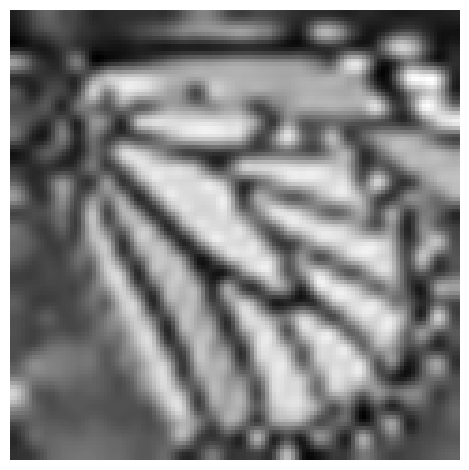

In [53]:
# Initial estimate for the HR image
X = y[0].reshape(SHAPE_LR) # Arbitrarily select the first image
X = X.data.cpu().numpy()
X = cv2.resize(X, (SHAPE_HR[1], SHAPE_HR[0]), interpolation = cv2.INTER_CUBIC)
disp(X, "sr_cubic.jpg")

In [54]:
X = X.reshape(N, 1)
X = torch.tensor(X, dtype = torch.float).to(DEVICE)
X = scale(X)
X.requires_grad = True

In [55]:
print("Initial PSNR: {:.3f}".format(PSNR(img, X).item()))

Initial PSNR: 13.913


In [56]:
Zx = priorCovariance(A=PRIOR_STRENGTH, r=PRIOR_CORR_LEN_SCALE, vi=V_HR)

In [57]:
Zx_inv    = torch.inverse(Zx)
logdet_Zx = logdetSPD(Zx)

Мы бы могли использовать корректное априорное, однако при оптимизации мы можем отбросить константы.

In [58]:
prior_dist = None

# prior_dist = MultivariateNormal(
#     torch.zeros(Zx.shape[0]).to(DEVICE),
#     covariance_matrix=Zx
# )

In [59]:
W = [transform(shifts[k], angles[k], gamma) for k in range(K)] # actual MxN Ws, not patches

In [60]:
N_EPOCH_MAX = 500
LR = 0.05 

optimizer = torch.optim.AdamW(
    [X],
    lr = LR
)

  0%|          | 0/500 [00:00<?, ?it/s]

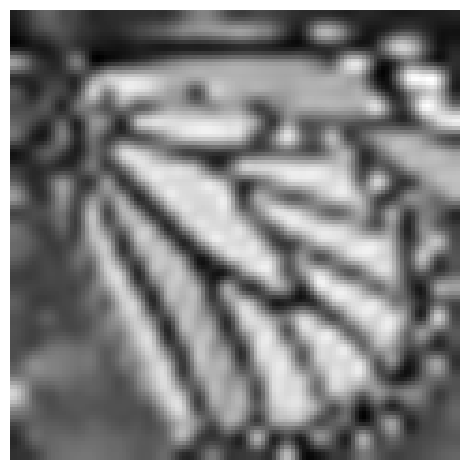

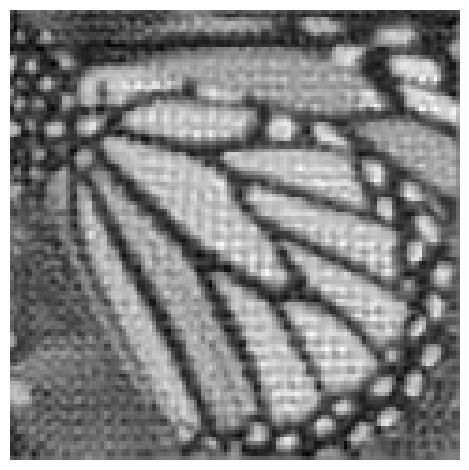

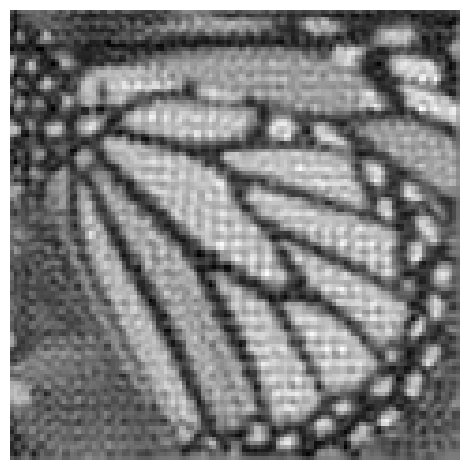

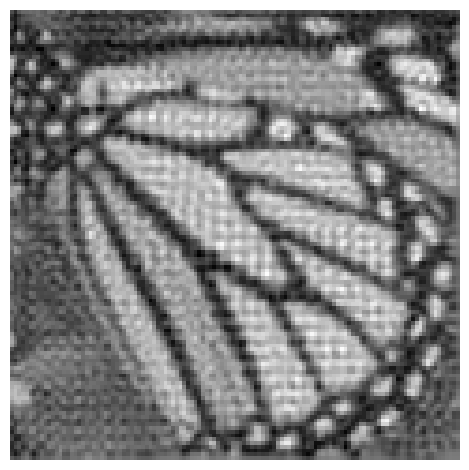

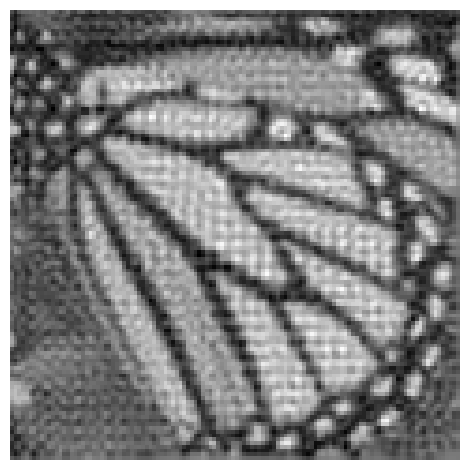

In [61]:
os.makedirs("GIF", exist_ok=True)

losses = []
pbar   = tqdm(range(N_EPOCH_MAX))
for i in pbar:

    if i % 100 == 0:
        disp(X.reshape(SHAPE_HR), f"GIF/{i}.jpg", show=True)
    elif i % 2 == 0:
        disp(X.reshape(SHAPE_HR), f"GIF/{i}.jpg", show=False)

    optimizer.zero_grad()

    torch.cuda.empty_cache()
    
    loss = -1*logPosteriorGaussian_UN(prior_dist=None, x=X, y=y, W=W, sigma=SIGMA_AGN)
    loss.backward()

    torch.cuda.empty_cache()

    optimizer.step()
    
    loss_scalar = loss.item()
    losses.append(loss_scalar)
    pbar.set_description(f"Loss: {loss_scalar:.3f}")

    torch.cuda.empty_cache()

In [62]:
X.requires_grad = False

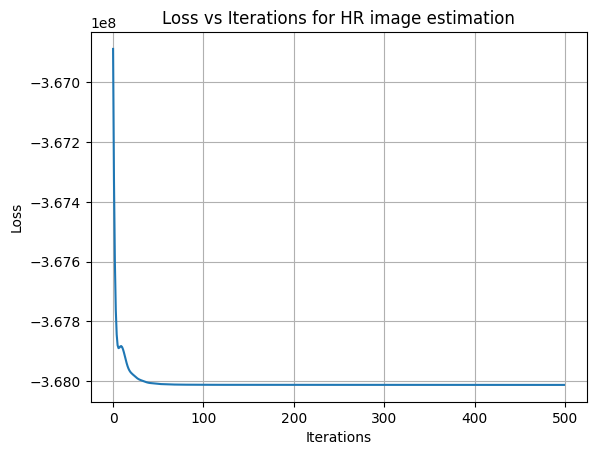

In [63]:
plt.plot(range(len(losses)), losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations for HR image estimation")
plt.grid()
plt.show()

### `Визуализация`

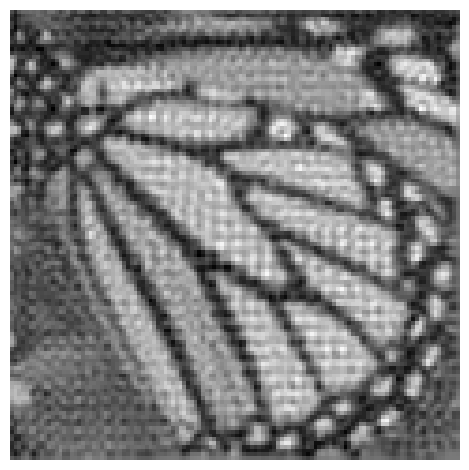

In [64]:
disp(X.reshape(SHAPE_HR), f"sr_GP_prior.jpg")

In [65]:
print("Final PSNR achieved: {:.3f}".format(PSNR(img, X).item()))

Final PSNR achieved: 17.933


In [66]:
# Create a GIF for visualization

import imageio
images = []

for i in range(0, N_EPOCH_MAX, 2):
    images.append(Image.open(f"GIF/{i}.jpg"))

imageio.mimsave("process.gif", images)

### `Замечание`

У нас возникало много проблем из-за матрицы $Z_x$. Она появилась, когда мы выбрали априорное распределение. Заметим, что мы всегда можем выбрать другое априорное распределение. Например, часто когда говорят про изображения берут [total variance](https://en.wikipedia.org/wiki/Total_variation_denoising).

Ниже пример кода, как можно использовать total variance в виде априорного распределения.

```python
TV_ALPHA = 15

def logPriorTV(x):
    """ Returns the log prior """
    
    x_2d = x.reshape(SHAPE_HR)

    x_t = torch.roll(x_2d, 1, 0)
    x_l = torch.roll(x_2d, 1, 1)
    
    d_t = x_2d - x_t
    d_l = x_2d - x_l
    
    log_prior = -TV_ALPHA * (torch.sum(torch.sqrt(d_t**2 + d_l**2)))

    return log_prior
```

### `Сравнение`

In [67]:
def vis_img(path, ax):
    im = Image.open(path)
    im = np.array(im)
    
    ax.set_title(path[:-4])
    ax.imshow(im, cmap='gray')
    ax.axis('off')

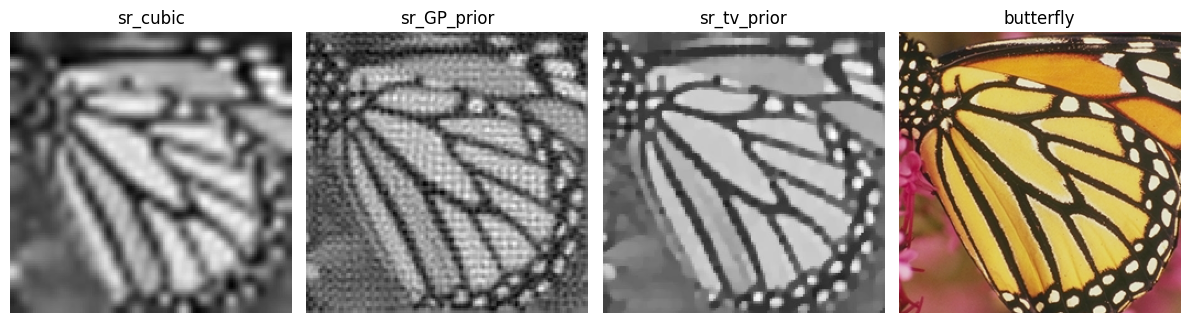

In [68]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))

for i, p in enumerate(["sr_cubic.jpg", "sr_GP_prior.jpg", "sr_tv_prior.jpg", "butterfly.png"]):
    vis_img(p, ax[i])

plt.tight_layout()
plt.savefig("results.png")